In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from math import sqrt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [ ]:
house_details_df=pd.read_csv('/content/House_Rent_Dataset.csv')

In [ ]:
house_details_df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [ ]:
house_details_df=house_details_df.rename(columns={
    'Posted On':'date',
    'BHK':'bhk',
    'Rent':'rent',
    'Size':'size',
    'Area Type':'area_type',
    'Area Locality':'area_locality',
    'City':'city',
    'Furnishing Status':'furnishing_status'
})

In [ ]:
print(f"NAN value: {int(house_details_df.isna().values.mean())}")
print(f"zero values: {int((house_details_df==0).values.mean())}")
print(f"Duplicate value: {house_details_df.duplicated().sum()}")

NAN value: 0
zero values: 0
Duplicate value: 0


In [ ]:
house_details_df.describe()

,bhk,rent,size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [ ]:
house_details_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               4746 non-null   object
 1   bhk                4746 non-null   int64 
 2   rent               4746 non-null   int64 
 3   size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   area_type          4746 non-null   object
 6   area_locality      4746 non-null   object
 7   city               4746 non-null   object
 8   furnishing_status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [ ]:
house_details_df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)

,0
area_locality,2235
Floor,480
date,81
city,6
area_type,3
furnishing_status,3
Tenant Preferred,3
Point of Contact,3


In [ ]:
target_cols=['city','Point of Contact','area_type','furnishing_status','Tenant Preferred']
counts=[]
for col in target_cols:
  vc=house_details_df[col].value_counts()
  counts.append(house_details_df[col].value_counts())
table=pd.DataFrame({'value':vc.index,'count':vc.values,'column':col})
counts.append(table)
summary_df=pd.concat(counts,ignore_index=True)
summary_df

,0,value,count,column
0,972.0,NaN,NaN,NaN
1,891.0,NaN,NaN,NaN
2,886.0,NaN,NaN,NaN
3,868.0,NaN,NaN,NaN
4,605.0,NaN,NaN,NaN
5,524.0,NaN,NaN,NaN
6,3216.0,NaN,NaN,NaN
7,1529.0,NaN,NaN,NaN
8,1.0,NaN,NaN,NaN
9,2446.0,NaN,NaN,NaN


In [ ]:
ds = house_details_df[(house_details_df['area_type'] != 'Built Area') & (house_details_df['Point of Contact'] != 'Contact Builder')]

In [ ]:
house_details_df[['rent','city']].groupby('city').describe()

rent                                                         \
           count          mean            std     min      25%      50%   
city                                                                      
Bangalore  886.0  24966.365688  120056.165622  3500.0   9500.0  14000.0   
Chennai    891.0  21614.092031   33069.910236  3000.0  10000.0  14000.0   
Delhi      605.0  29461.983471   43542.047016  2000.0  11000.0  17000.0   
Hyderabad  868.0  20555.048387   26436.196407  1200.0  10000.0  14000.0   
Kolkata    524.0  11645.173664   11137.494632  1500.0   6150.0   8500.0   
Mumbai     972.0  85321.204733  102525.116720  4500.0  32000.0  52000.0   

                               
               75%        max  
city                           
Bangalore  21000.0  3500000.0  
Chennai    21500.0   600000.0  
Delhi      30000.0   530000.0  
Hyderabad  22000.0   400000.0  
Kolkata    14000.0   180000.0  
Mumbai     95000.0  1200000.0

In [ ]:
print(ds.sort_values(by='rent',ascending=False).head())

            date  bhk     rent  size         Floor    area_type  \
1837  2022-06-08    3  3500000  2500    4 out of 4  Carpet Area   
1001  2022-06-01    4  1200000  5000   4 out of 15  Carpet Area   
827   2022-05-18    4  1000000  3064  18 out of 45  Carpet Area   
1329  2022-06-23    4   850000  3200    2 out of 4  Carpet Area   
1459  2022-06-27    4   700000  3200  24 out of 24  Carpet Area   

                area_locality       city furnishing_status  Tenant Preferred  \
1837             Marathahalli  Bangalore    Semi-Furnished         Bachelors   
1001                     Juhu     Mumbai    Semi-Furnished  Bachelors/Family   
827     Raheja Artesia, Worli     Mumbai    Semi-Furnished            Family   
1329             Breach Candy     Mumbai         Furnished  Bachelors/Family   
1459  Lady Ratan Tower, Worli     Mumbai         Furnished  Bachelors/Family   

      Bathroom Point of Contact  
1837         3    Contact Agent  
1001         4    Contact Agent  
827          4

/tmp/ipython-input-14-2453072867.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


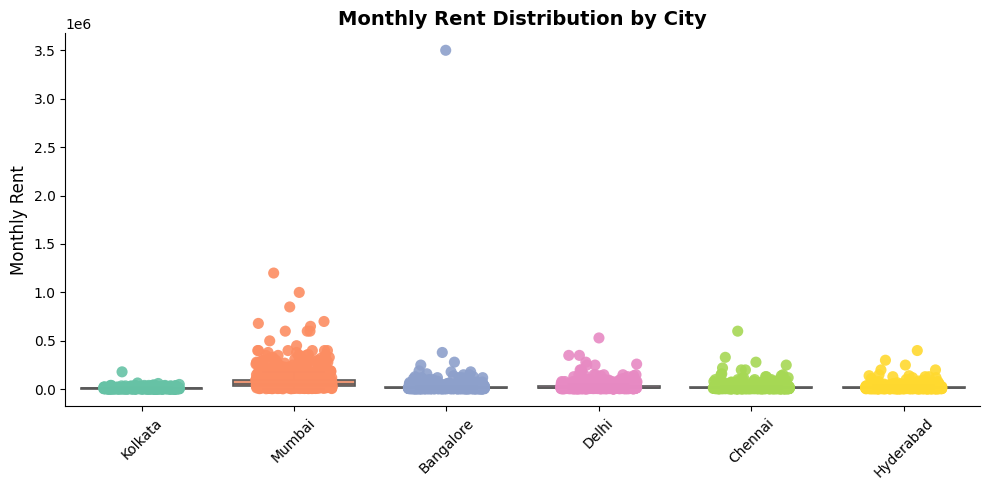

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.figure(figsize=(10, 5))
sns.boxplot(x='city', y='rent', data=ds, showfliers=False, palette='Set2', linewidth=1.2)
sns.stripplot(x='city', y='rent', data=ds, hue='city', dodge=False, palette='Set2',
              jitter=0.25, size=8, alpha=0.9)
plt.legend().remove()
plt.xticks(rotation=45, fontsize=10)
plt.title('Monthly Rent Distribution by City', fontsize=14, weight='bold')
plt.ylabel('Monthly Rent', fontsize=12)
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
ds.rent.sort_values().tail(10)

,rent
1384,600000
792,600000
726,600000
1319,650000
1484,680000
1459,700000
1329,850000
827,1000000
1001,1200000
1837,3500000


In [ ]:
ds.loc[[1837]]

,date,bhk,rent,size,Floor,area_type,area_locality,city,furnishing_status,Tenant Preferred,Bathroom,Point of Contact
1837,2022-06-08,3,3500000,2500,4 out of 4,Carpet Area,Marathahalli,Bangalore,Semi-Furnished,Bachelors,3,Contact Agent


In [ ]:
ds=ds.drop(index=[1837])
upper_limit=ds.rent.quantile(0.99)
ds=ds[ds['rent']<=upper_limit]

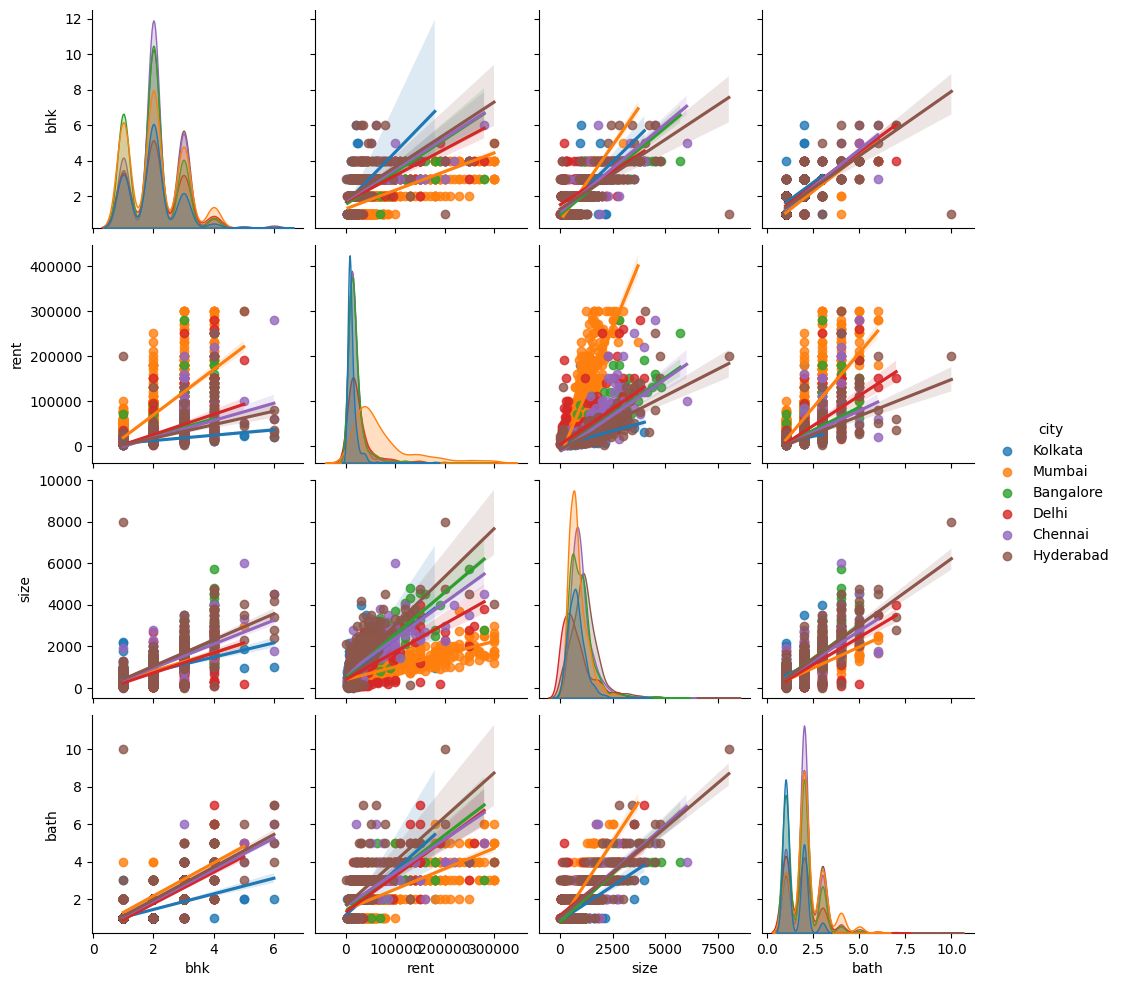

In [ ]:
warnings.filterwarnings('ignore')
ds.rename(columns={'Floor': 'floor', 'furnishing_status': 'furnish', 'Bathroom': 'bath'}, inplace=True)
sns.pairplot(ds[['bhk','rent','size','floor','furnish','bath','city']],hue='city',kind='reg')

In [ ]:
ds.bath.sort_values().tail(10)

,bath
1093,6
3584,6
1489,6
2849,6
1160,6
4409,6
4350,7
4518,7
2846,7
4185,10


In [ ]:
ds=ds.drop(index=[4185])

In [ ]:
ds=ds.drop(columns=['date','area_locality','Tenant Preferred'])

In [ ]:
ds['furnish']=ds['furnish'].replace({'Unfurnished': 0, 'Semi-Furnished': 0.5, 'Furnished':1.0})

In [ ]:
for old, new in {'Ground': '0', 'Upper': '-1', 'Lower': '-2'}.items():
    ds.floor = ds.floor.str.replace(old, new)
ds['max_floor'] = ds.floor.apply(lambda x: int(x.split(' ')[-1]))
ds['floor'] = ds.floor.apply(lambda x: int(x.split(' ')[0]))

In [ ]:
ds = pd.get_dummies(ds, columns=['city', 'Point of Contact', 'area_type'], drop_first=True)

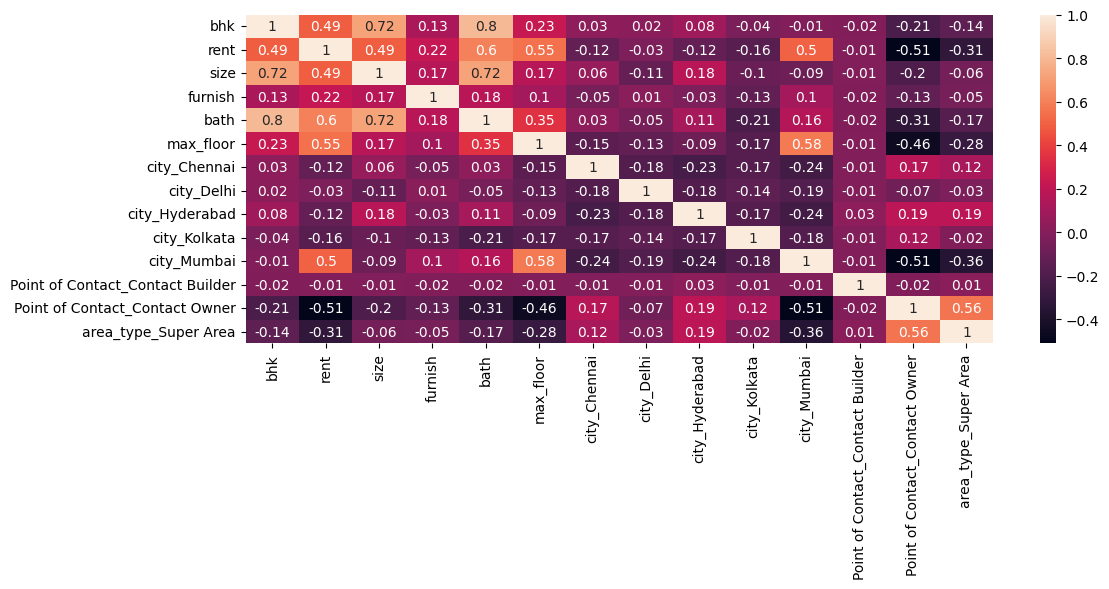

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
ds_numeric = ds.drop(columns=[ 'floor'])
sns.heatmap(ds_numeric.corr().round(2), annot=True, ax=ax)
fig.tight_layout()

In [ ]:
ds_core = ds[ds['city_Mumbai'] == 0].copy()
ds_core.drop(columns=['city_Mumbai'], inplace=True)

ds_core['Point of Contact_Contact Owner'] = ds_core['Point of Contact_Contact Owner'].astype(int)
ds_core['area_type_Super Area'] = ds_core['area_type_Super Area'].astype(int)
ds_core['city_Chennai'] = ds_core['city_Chennai'].astype(int)
ds_core['city_Delhi'] = ds_core['city_Delhi'].astype(int)
ds_core['city_Hyderabad'] = ds_core['city_Hyderabad'].astype(int)
ds_core['city_Kolkata'] = ds_core['city_Kolkata'].astype(int)


In [ ]:
X = ds_core[['bhk', 'size', 'floor', 'bath', 'furnish', 'max_floor', 'Point of Contact_Contact Owner', 'area_type_Super Area', 'city_Chennai',   'city_Delhi',   'city_Hyderabad',       'city_Kolkata']]

X = add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                           feature        VIF
0                            const  21.449871
1                              bhk   3.182241
2                             size   2.740955
3                            floor   2.637148
4                             bath   3.635954
5                          furnish   1.074257
6                        max_floor   2.796391
7   Point of Contact_Contact Owner   1.496516
8             area_type_Super Area   1.254256
9                     city_Chennai   1.579858
10                      city_Delhi   1.564159
11                  city_Hyderabad   1.599909
12                    city_Kolkata   1.524786


In [ ]:
features = ['size', 'area_type_Super Area', 'bath', 'furnish', 'max_floor', 'floor', 'Point of Contact_Contact Owner', 'bhk', 'city_Chennai',    'city_Delhi',   'city_Hyderabad',       'city_Kolkata']

X = ds_core[features]
y = np.log1p(ds_core['rent'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model_l = LinearRegression()
model_l.fit(X_train, y_train)

pred_train = np.expm1(model_l.predict(X_train))
pred_test = np.expm1(model_l.predict(X_test))
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)

print("Train")
print(f"MSE: {mean_squared_error(y_train_orig, pred_train)}")
print(f"MAPE: {mean_absolute_percentage_error(y_train_orig, pred_train)}")
print(f"RSQ: {r2_score(y_train_orig, pred_train)}")
print(f"RMSE: {sqrt(mean_squared_error(y_train_orig, pred_train))} mean:{int(ds_core.rent.mean())}")

print("\nTest")
print(f"MSE: {mean_squared_error(y_test_orig, pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_orig, pred_test)}")
print(f"RSQ: {r2_score(y_test_orig, pred_test)}")
print(f"RMSE: {sqrt(mean_squared_error(y_test_orig, pred_test))} mean:{int(ds_core.rent.mean())}")

Train
MSE: 270775111.04801387
MAPE: 0.30095941376914775
RSQ: 0.5660961859461208
RMSE: 16455.245700019612 mean:20325

Test
MSE: 195401274.69572487
MAPE: 0.2746641035331677
RSQ: 0.6760080590997115
RMSE: 13978.60059861948 mean:20325


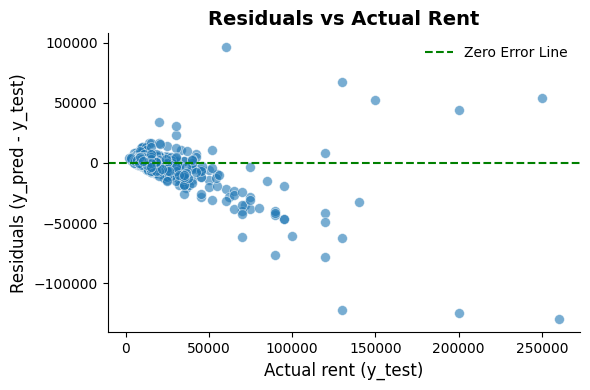

In [ ]:
plt.figure(figsize=(6, 4))

sns.scatterplot(x=y_test_orig, y=pred_test - y_test_orig, alpha=0.6, s=50, color="#1f77b4", edgecolor='white', linewidth=0.5)
plt.axhline(y=0, color='green', linestyle='--', linewidth=1.5, label='Zero Error Line')

plt.xlabel("Actual rent (y_test)", fontsize=12)
plt.ylabel("Residuals (y_pred - y_test)", fontsize=12)
plt.title("Residuals vs Actual Rent", fontsize=14, weight='bold')
plt.legend(frameon=False)
sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

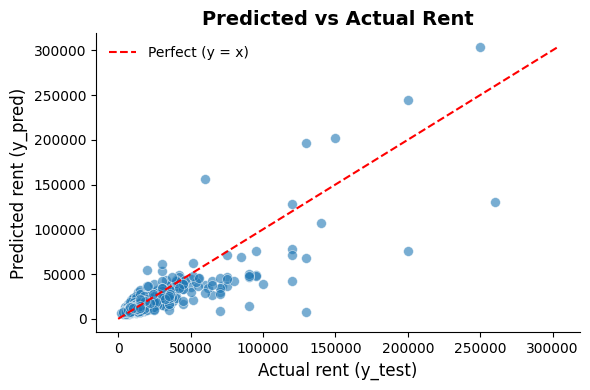

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test_orig, y=pred_test, alpha=0.6, s=50, color="#1f77b4", edgecolor='white', linewidth=0.5)

max_val = max(y_test_orig.max(), pred_test.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect (y = x)')

plt.xlabel("Actual rent (y_test)", fontsize=12)
plt.ylabel("Predicted rent (y_pred)", fontsize=12)
plt.title("Predicted vs Actual Rent", fontsize=14, weight='bold')
plt.legend(frameon=False)
sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()